# Model Comparison: CNN vs ViT (Brain Tumor Detection)

这个 notebook 用同一套数据切分和评估指标，对比 CNN 与 Vision Transformer（ViT）在脑肿瘤二分类任务上的表现。

In [1]:
# 环境自检：先运行这个 cell，确认解释器和依赖是否正确
import sys
import importlib

required_packages = {
    'tensorflow': 'tensorflow',
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
}

print('=== Python 环境信息 ===')
print('Python executable:', sys.executable)
print('Python version   :', sys.version.split()[0])

print('\n=== 依赖检查 ===')
missing = []
for module_name, pip_name in required_packages.items():
    try:
        importlib.import_module(module_name)
        print(f'[OK] {module_name}')
    except Exception as e:
        err = str(e)
        missing.append((module_name, pip_name, err))
        print(f'[MISSING] {module_name} -> pip install {pip_name}')
        print(f'         reason: {err}')

if missing:
    print('\n缺失依赖（请在当前环境安装）：')
    for _, pip_name, _ in missing:
        print(f'  pip install {pip_name}')

    print('\n若 tensorflow 导入失败并且报 DLL / path 相关错误：')
    print('- 请切换 notebook kernel 到: Python 3.11 (Brain)')
    print('- 或者使用短路径虚拟环境（例如 C:\\venv311bt）')
else:
    print('\n依赖完整，可以继续从上到下运行 notebook。')

=== Python 环境信息 ===
Python executable: C:\venv311bt\Scripts\python.exe
Python version   : 3.11.9

=== 依赖检查 ===


[OK] tensorflow
[OK] numpy
[OK] pandas
[OK] matplotlib


[OK] seaborn
[OK] sklearn

依赖完整，可以继续从上到下运行 notebook。


In [2]:
# 如果缺少依赖，请先安装（首次运行需要）
# %pip install -q tensorflow seaborn scikit-learn

import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except Exception as e:
    raise ImportError(
        'TensorFlow 导入失败。请先确认当前 kernel 环境已安装 tensorflow，'
        '并优先使用 Python 3.11 的虚拟环境。原始错误: ' + str(e)
    )

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_score, recall_score

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# 快速调试模式：减少图编译/Autograph 引发的问题
tf.config.run_functions_eagerly(True)
tf.data.experimental.enable_debug_mode()

print('TensorFlow:', tf.__version__)

TensorFlow: 2.21.0


In [3]:
PROJECT_ROOT = Path.cwd()
META_PATH = PROJECT_ROOT / 'metadata_rgb_only.csv'
DATA_ROOT = PROJECT_ROOT / 'Brain Tumor Data Set' / 'Brain Tumor Data Set'
TUMOR_DIR = DATA_ROOT / 'Brain Tumor'
HEALTHY_DIR = DATA_ROOT / 'Healthy'

if not META_PATH.exists():
    raise FileNotFoundError(f'Metadata not found: {META_PATH}')

if not TUMOR_DIR.exists() or not HEALTHY_DIR.exists():
    raise FileNotFoundError('Dataset folders not found. Please check directory names.')

df = pd.read_csv(META_PATH, index_col=0)
df['label'] = (df['class'] == 'tumor').astype('int32')

def resolve_path(row):
    folder = TUMOR_DIR if row['class'] == 'tumor' else HEALTHY_DIR
    return str(folder / row['image'])

df['path'] = df.apply(resolve_path, axis=1)
df = df[df['path'].map(lambda p: Path(p).exists())].copy()
df = df[['path', 'label']]

print('Total samples:', len(df))
print(df['label'].value_counts().rename(index={0: 'normal', 1: 'tumor'}))

Total samples: 4461
label
tumor     2421
normal    2040
Name: count, dtype: int64


In [4]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df['label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df['label']
)

# 快速模式：仅抽样部分数据先做对比趋势（分层抽样）
QUICK_MODE = True
QUICK_FRACTION = 0.25

def stratified_subsample(dataframe, frac, seed=SEED):
    sampled, _ = train_test_split(
        dataframe,
        train_size=frac,
        random_state=seed,
        stratify=dataframe['label']
    )
    return sampled.reset_index(drop=True)

if QUICK_MODE:
    train_df = stratified_subsample(train_df, QUICK_FRACTION)
    val_df = stratified_subsample(val_df, QUICK_FRACTION)
    test_df = stratified_subsample(test_df, QUICK_FRACTION)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)} | QUICK_MODE={QUICK_MODE}')

Train: 780 | Val: 167 | Test: 167 | QUICK_MODE=True


In [5]:
IMG_SIZE = 128
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

# 为了稳定运行（避免 tf.data map/autograph 兼容问题），快速模式直接预加载到内存
from tensorflow.keras.utils import load_img, img_to_array


def load_images_and_labels(dataframe):
    images = []
    labels = []
    for _, row in dataframe.iterrows():
        image = load_img(row['path'], target_size=(IMG_SIZE, IMG_SIZE))
        image = img_to_array(image).astype('float32') / 255.0
        images.append(image)
        labels.append(float(row['label']))
    return np.array(images, dtype='float32'), np.array(labels, dtype='float32')


x_train, y_train = load_images_and_labels(train_df)
x_val, y_val = load_images_and_labels(val_df)
x_test, y_test = load_images_and_labels(test_df)


def make_dataset_from_arrays(x, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(buffer_size=len(x), seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset_from_arrays(x_train, y_train, training=True)
val_ds = make_dataset_from_arrays(x_val, y_val, training=False)
test_ds = make_dataset_from_arrays(x_test, y_test, training=False)

print(f'IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE}')
print(f'x_train={x_train.shape}, x_val={x_val.shape}, x_test={x_test.shape}')

IMG_SIZE=128, BATCH_SIZE=16
x_train=(780, 128, 128, 3), x_val=(167, 128, 128, 3), x_test=(167, 128, 128, 3)


In [6]:
def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(16, 3, activation='relu')(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(32, 3, activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inputs, outputs, name='CNN_Light')


def mlp_block(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation='gelu')(x)
        x = layers.Dropout(dropout_rate)(x)
    return x


def transformer_encoder(x, projection_dim, num_heads, transformer_units, dropout_rate):
    # LN + MHA + 残差
    x1 = layers.LayerNormalization(epsilon=1e-6)(x)
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=projection_dim, dropout=dropout_rate
    )(x1, x1)
    x2 = layers.Add()([x, attention_output])

    # LN + MLP + 残差
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    x3 = mlp_block(x3, hidden_units=transformer_units, dropout_rate=dropout_rate)
    return layers.Add()([x2, x3])


def build_transformer_classifier(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    projection_dim=64,
    num_heads=4,
    transformer_layers=4,
    transformer_units=(128, 64),
    mlp_head_units=(128, 64),
    dropout_rate=0.1,
):
    inputs = keras.Input(shape=input_shape)

    # 把图像网格化为 token：每个 16x16 patch -> 一个 token
    patches = layers.Conv2D(
        filters=projection_dim,
        kernel_size=16,
        strides=16,
        padding='valid'
    )(inputs)
    h = input_shape[0] // 16
    w = input_shape[1] // 16
    num_patches = h * w

    x = layers.Reshape((num_patches, projection_dim))(patches)

    # 可学习位置编码
    positions = tf.range(start=0, limit=num_patches, delta=1)
    position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)(positions)
    x = x + position_embedding

    for _ in range(transformer_layers):
        x = transformer_encoder(x, projection_dim, num_heads, transformer_units, dropout_rate)

    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = mlp_block(x, hidden_units=mlp_head_units, dropout_rate=dropout_rate)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return keras.Model(inputs, outputs, name='Transformer_Light')


METRICS = [
    keras.metrics.BinaryAccuracy(name='accuracy'),
    keras.metrics.AUC(name='auc'),
    keras.metrics.Precision(name='precision'),
    keras.metrics.Recall(name='recall'),
]


def train_model(model, train_data, val_data, epochs=4, lr=1e-4):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=METRICS,
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_auc', mode='max', patience=2, restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=1, verbose=1
        ),
    ]

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1,
    )
    return history


In [7]:
EPOCHS = 1

cnn_model = build_cnn()
cnn_history = train_model(cnn_model, train_ds, val_ds, epochs=EPOCHS, lr=1e-4)

vit_model = build_transformer_classifier()
vit_history = train_model(vit_model, train_ds, val_ds, epochs=EPOCHS, lr=2e-4)

 1/49 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.4375 - auc: 0.5083 - loss: 0.7072 - precision: 0.4000 - recall: 1.0000

 2/49 ━━━━━━━━━━━━━━━━━━━━ 10s 218ms/step - accuracy: 0.4688 - auc: 0.4846 - loss: 0.7028 - precision: 0.4500 - recall: 0.8125

 3/49 ━━━━━━━━━━━━━━━━━━━━ 9s 216ms/step - accuracy: 0.4792 - auc: 0.4676 - loss: 0.7020 - precision: 0.4806 - recall: 0.7083 

 4/49 ━━━━━━━━━━━━━━━━━━━━ 9s 215ms/step - accuracy: 0.4805 - auc: 0.4628 - loss: 0.7015 - precision: 0.4904 - recall: 0.6268

 5/49 ━━━━━━━━━━━━━━━━━━━━ 9s 217ms/step - accuracy: 0.4819 - auc: 0.4654 - loss: 0.7010 - precision: 0.4986 - recall: 0.5805

...

46/49 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5766 - auc: 0.5847 - loss: 0.6956 - precision: 0.6043 - recall: 0.6693

47/49 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.5759 - auc: 0.5838 - loss: 0.6957 - precision: 0.6034 - recall: 0.6690

48/49 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5753 - auc: 0.5831 - loss: 0.6957 - precision: 0.6027 - recall: 0.6689

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5747 - auc: 0.5824 - loss: 0.6957 - precision: 0.6020 - recall: 0.6688

49/49 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.5459 - auc: 0.5478 - loss: 0.6969 - precision: 0.5698 - recall: 0.6673 - val_accuracy: 0.5449 - val_auc: 0.5433 - val_loss: 0.6872 - val_precision: 0.5449 - val_recall: 1.0000 - learning_rate: 2.0000e-04


In [8]:
def evaluate_model(name, model, dataset):
    eval_dict = model.evaluate(dataset, verbose=0, return_dict=True)

    y_prob = model.predict(dataset, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = np.concatenate([y.numpy().astype(int) for _, y in dataset], axis=0)

    # 先从模型返回指标拿；拿不到就用 sklearn 兜底
    accuracy = eval_dict.get('accuracy', eval_dict.get('binary_accuracy', np.nan))
    auc_score = eval_dict.get('auc', np.nan)
    precision = eval_dict.get('precision', np.nan)
    recall = eval_dict.get('recall', np.nan)

    if pd.isna(accuracy):
        accuracy = (y_pred == y_true).mean()
    if pd.isna(auc_score):
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_score = auc(fpr, tpr)
    if pd.isna(precision):
        precision = precision_score(y_true, y_pred, zero_division=0)
    if pd.isna(recall):
        recall = recall_score(y_true, y_pred, zero_division=0)

    metric_dict = {
        'accuracy': float(accuracy),
        'auc': float(auc_score),
        'precision': float(precision),
        'recall': float(recall),
    }

    report = classification_report(
        y_true,
        y_pred,
        target_names=['normal', 'tumor'],
        output_dict=True,
        zero_division=0,
    )
    cm = confusion_matrix(y_true, y_pred)

    return {
        'name': name,
        'metrics': metric_dict,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'report': report,
        'cm': cm,
    }

cnn_result = evaluate_model(cnn_model.name, cnn_model, test_ds)
vit_result = evaluate_model(vit_model.name, vit_model, test_ds)

summary_df = pd.DataFrame([
    {
        'Model': cnn_result['name'],
        'Accuracy': cnn_result['metrics']['accuracy'],
        'AUC': cnn_result['metrics']['auc'],
        'Precision': cnn_result['metrics']['precision'],
        'Recall': cnn_result['metrics']['recall'],
        'F1 (tumor)': cnn_result['report']['tumor']['f1-score'],
    },
    {
        'Model': vit_result['name'],
        'Accuracy': vit_result['metrics']['accuracy'],
        'AUC': vit_result['metrics']['auc'],
        'Precision': vit_result['metrics']['precision'],
        'Recall': vit_result['metrics']['recall'],
        'F1 (tumor)': vit_result['report']['tumor']['f1-score'],
    },
]).sort_values('Accuracy', ascending=False)

print(summary_df.to_string(index=False))


            Model  Accuracy      AUC  Precision   Recall  F1 (tumor)
        CNN_Light  0.634731 0.728239   0.702703 0.571429    0.630303
Transformer_Light  0.544910 0.563693   0.544910 1.000000    0.705426


CNN report:

              precision    recall  f1-score   support

      normal       0.58      0.71      0.64        76
       tumor       0.70      0.57      0.63        91

    accuracy                           0.63       167
   macro avg       0.64      0.64      0.63       167
weighted avg       0.65      0.63      0.63       167


ViT report:

              precision    recall  f1-score   support

      normal       0.00      0.00      0.00        76
       tumor       0.54      1.00      0.71        91

    accuracy                           0.54       167
   macro avg       0.27      0.50      0.35       167
weighted avg       0.30      0.54      0.38       167



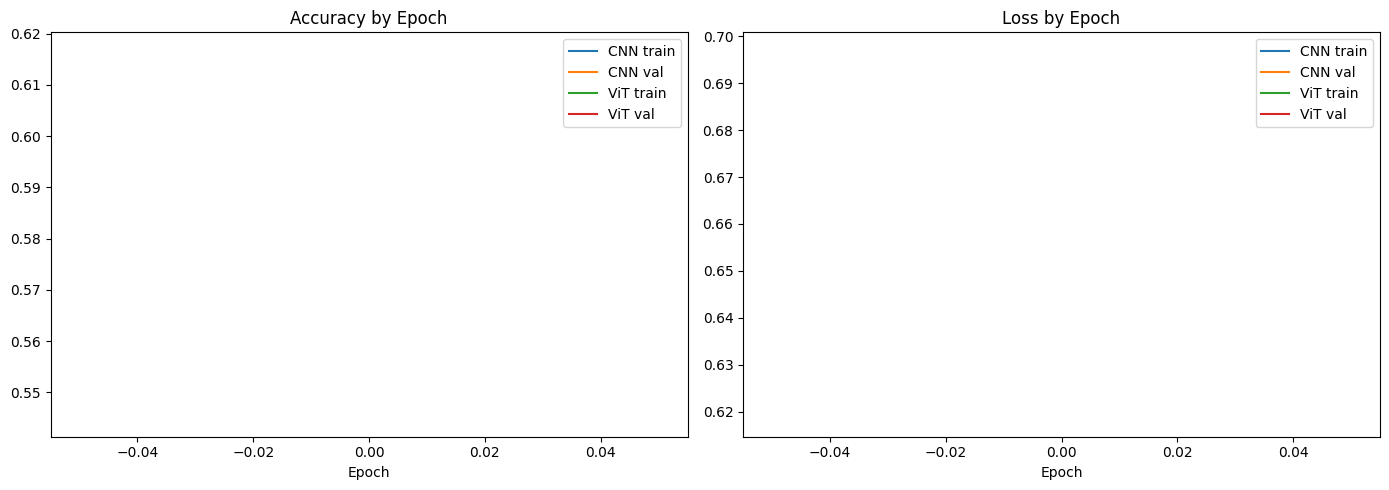

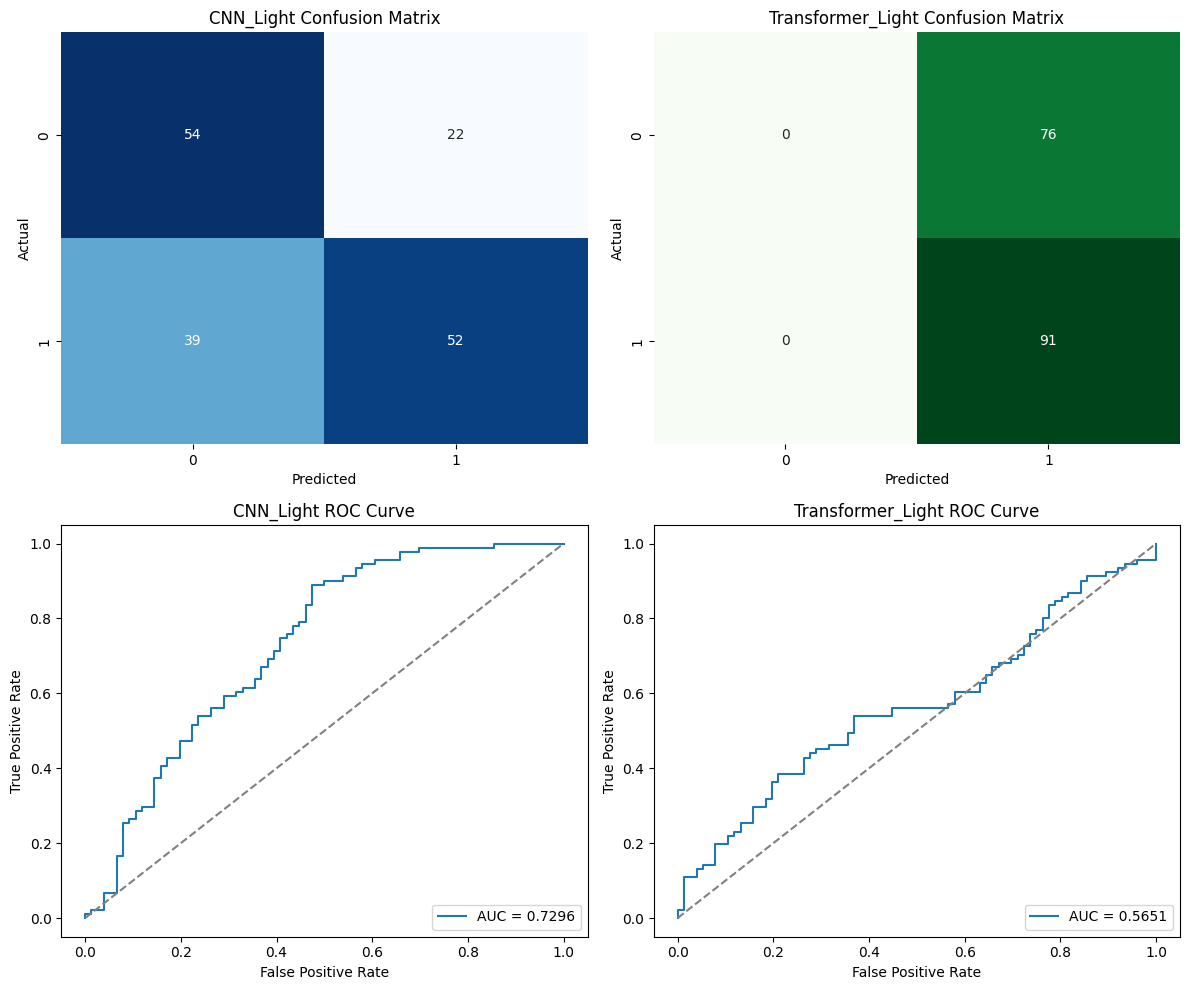

In [9]:
def pick_hist_key(hist_dict, candidates):
    for k in candidates:
        if k in hist_dict:
            return k
    return None


def plot_history(cnn_hist, vit_hist):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cnn_acc = pick_hist_key(cnn_hist.history, ['accuracy', 'binary_accuracy'])
    cnn_val_acc = pick_hist_key(cnn_hist.history, ['val_accuracy', 'val_binary_accuracy'])
    vit_acc = pick_hist_key(vit_hist.history, ['accuracy', 'binary_accuracy'])
    vit_val_acc = pick_hist_key(vit_hist.history, ['val_accuracy', 'val_binary_accuracy'])

    if cnn_acc and cnn_val_acc and vit_acc and vit_val_acc:
        axes[0].plot(cnn_hist.history[cnn_acc], label='CNN train')
        axes[0].plot(cnn_hist.history[cnn_val_acc], label='CNN val')
        axes[0].plot(vit_hist.history[vit_acc], label='ViT train')
        axes[0].plot(vit_hist.history[vit_val_acc], label='ViT val')
    else:
        axes[0].text(0.1, 0.5, 'accuracy history key not found', fontsize=11)

    axes[0].set_title('Accuracy by Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(cnn_hist.history['loss'], label='CNN train')
    axes[1].plot(cnn_hist.history['val_loss'], label='CNN val')
    axes[1].plot(vit_hist.history['loss'], label='ViT train')
    axes[1].plot(vit_hist.history['val_loss'], label='ViT val')
    axes[1].set_title('Loss by Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()


def plot_confusion_and_roc(result_a, result_b):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    sns.heatmap(result_a['cm'], annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 0])
    axes[0, 0].set_title(f"{result_a['name']} Confusion Matrix")
    axes[0, 0].set_xlabel('Predicted')
    axes[0, 0].set_ylabel('Actual')

    sns.heatmap(result_b['cm'], annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[0, 1])
    axes[0, 1].set_title(f"{result_b['name']} Confusion Matrix")
    axes[0, 1].set_xlabel('Predicted')
    axes[0, 1].set_ylabel('Actual')

    for result, ax in [(result_a, axes[1, 0]), (result_b, axes[1, 1])]:
        fpr, tpr, _ = roc_curve(result['y_true'], result['y_prob'])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
        ax.plot([0, 1], [0, 1], '--', color='gray')
        ax.set_title(f"{result['name']} ROC Curve")
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.legend(loc='lower right')

    plt.tight_layout()


if 'summary_df' not in globals():
    raise RuntimeError('请先运行评估 cell（会生成 summary_df）再运行可视化 cell。')

plot_history(cnn_history, vit_history)
plot_confusion_and_roc(cnn_result, vit_result)

print('CNN report:\n')
print(classification_report(cnn_result['y_true'], cnn_result['y_pred'], target_names=['normal', 'tumor'], zero_division=0))
print('\nViT report:\n')
print(classification_report(vit_result['y_true'], vit_result['y_pred'], target_names=['normal', 'tumor'], zero_division=0))

In [10]:
# 自动结论：谁更好 + 提升幅度 + 关键说明
if 'summary_df' not in globals():
    raise RuntimeError('请先运行评估 cell（会生成 summary_df）再运行自动结论。')

metric_priority = ['Accuracy', 'AUC', 'F1 (tumor)']

ranked = summary_df.sort_values(metric_priority, ascending=False).reset_index(drop=True)
best = ranked.iloc[0]
runner_up = ranked.iloc[1]

acc_gap = (best['Accuracy'] - runner_up['Accuracy']) * 100
auc_gap = (best['AUC'] - runner_up['AUC']) * 100
f1_gap = (best['F1 (tumor)'] - runner_up['F1 (tumor)']) * 100

print('=== 自动结论 ===')
print(f"在当前数据切分和参数下，表现最好的模型是: {best['Model']}")
print(f"准确率提升: {acc_gap:.2f}%")
print(f"AUC 提升: {auc_gap:.2f}%")
print(f"肿瘤类 F1 提升: {f1_gap:.2f}%")

# 更关注漏诊风险时，优先看 Recall（tumor）
cnn_tumor_recall = cnn_result['report']['tumor']['recall']
vit_tumor_recall = vit_result['report']['tumor']['recall']

if cnn_tumor_recall > vit_tumor_recall:
    recall_best_name = cnn_result['name']
    recall_best_value = cnn_tumor_recall
elif vit_tumor_recall > cnn_tumor_recall:
    recall_best_name = vit_result['name']
    recall_best_value = vit_tumor_recall
else:
    recall_best_name = '两者相同'
    recall_best_value = cnn_tumor_recall

print('\n=== 医疗场景补充判断（看肿瘤召回率 Recall）===')
if recall_best_name == '两者相同':
    print(f"两者肿瘤召回率相同: {recall_best_value:.4f}")
else:
    print(f"肿瘤召回率更高的是: {recall_best_name} ({recall_best_value:.4f})")

print('\n建议：')
print('- 若你更看重总体准确率和综合指标，优先选自动结论中的第一名。')
print('- 若你更看重减少漏检（漏掉肿瘤），优先选肿瘤 Recall 更高的模型。')

=== 自动结论 ===
在当前数据切分和参数下，表现最好的模型是: CNN_Light
准确率提升: 8.98%
AUC 提升: 16.45%
肿瘤类 F1 提升: -7.51%

=== 医疗场景补充判断（看肿瘤召回率 Recall）===
肿瘤召回率更高的是: Transformer_Light (1.0000)

建议：
- 若你更看重总体准确率和综合指标，优先选自动结论中的第一名。
- 若你更看重减少漏检（漏掉肿瘤），优先选肿瘤 Recall 更高的模型。


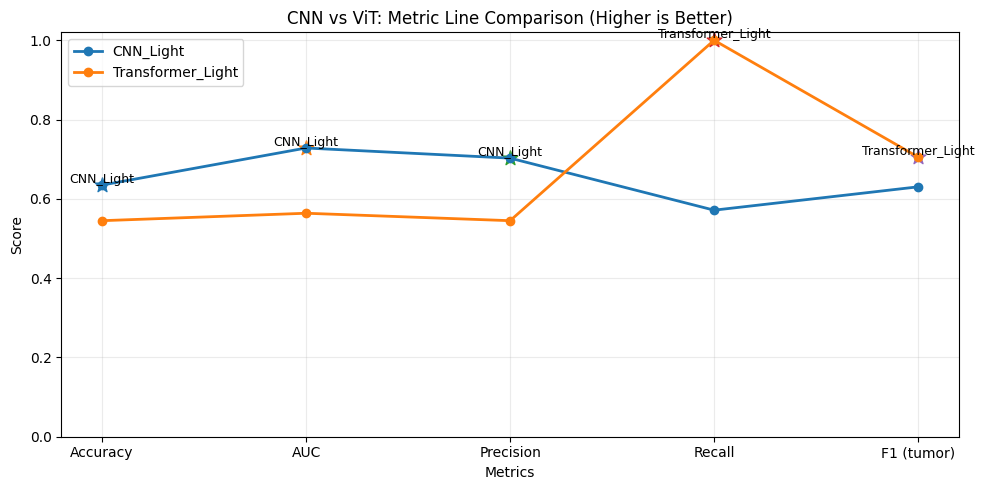

=== 线型图综合结论 ===
总体最优模型: Transformer_Light
相对 CNN_Light 的平均指标领先: 1.83%
            Model  OverallScore  Accuracy      AUC  Precision   Recall  F1 (tumor)
Transformer_Light      0.671788  0.544910 0.563693   0.544910 1.000000    0.705426
        CNN_Light      0.653481  0.634731 0.728239   0.702703 0.571429    0.630303

图已保存到: model_comparison_line.png


In [11]:
# 结尾线型图：两个模型的关键指标对比 + 自动标注更优模型
if 'summary_df' not in globals():
    raise RuntimeError('请先运行评估 cell（会生成 summary_df）再运行线型图。')

metrics_cols = ['Accuracy', 'AUC', 'Precision', 'Recall', 'F1 (tumor)']

plot_df = summary_df[['Model'] + metrics_cols].copy().set_index('Model')

plt.figure(figsize=(10, 5))
for model_name in plot_df.index:
    plt.plot(metrics_cols, plot_df.loc[model_name, metrics_cols], marker='o', linewidth=2, label=model_name)

# 每个指标位置标注最佳模型
for i, metric in enumerate(metrics_cols):
    best_row = summary_df.loc[summary_df[metric].idxmax()]
    best_model = best_row['Model']
    best_value = best_row[metric]
    plt.scatter([metric], [best_value], s=120, marker='*')
    plt.text(i, best_value + 0.005, f"{best_model}", ha='center', fontsize=9)

plt.ylim(0.0, 1.02)
plt.title('CNN vs ViT: Metric Line Comparison (Higher is Better)')
plt.ylabel('Score')
plt.xlabel('Metrics')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig('model_comparison_line.png', dpi=300, bbox_inches='tight')
plt.show()

# 综合分（简单平均）用于给出“谁最好”的总体结论
overall = summary_df.copy()
overall['OverallScore'] = overall[metrics_cols].mean(axis=1)
overall = overall.sort_values('OverallScore', ascending=False).reset_index(drop=True)

best_model = overall.loc[0, 'Model']
second_model = overall.loc[1, 'Model']
gap = (overall.loc[0, 'OverallScore'] - overall.loc[1, 'OverallScore']) * 100

print('=== 线型图综合结论 ===')
print(f"总体最优模型: {best_model}")
print(f"相对 {second_model} 的平均指标领先: {gap:.2f}%")
print(overall[['Model', 'OverallScore'] + metrics_cols].to_string(index=False))
print('\n图已保存到: model_comparison_line.png')